In [1]:
# regression-multiple-methods.ipynb

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
# To ensure reproducibility
np.random.seed(42)

# Read data from Excel file
file_path = 'regression-multiple-methods.xlsx'
train_data = pd.read_excel(file_path, sheet_name='train')
test_data = pd.read_excel(file_path, sheet_name='test')
print(train_data.head())
print(test_data.head())

          y        x1
0  0.009195  7.614286
1 -0.252077  7.621429
2 -0.028840  7.628571
3  0.160705  7.642857
4  0.283055  7.650000
          y        x1
0 -0.058062  7.607143
1  0.481502  7.635714
2  0.284487  7.692857
3  0.689126  7.700000
4  1.122109  7.707143


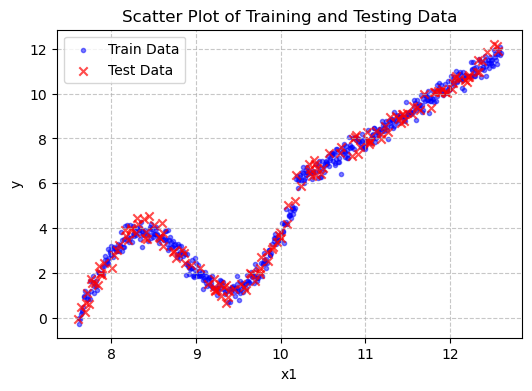

In [3]:
# Scatter Plot with 'x1' and 'y' columns ---

# Select the specified columns
x_train = train_data['x1']
y_train = train_data['y']
x_test = test_data['x1']
y_test = test_data['y']

# Create the scatter plot
plt.figure(figsize=(6, 4))

# Scatter plot for training data (blue circles)
plt.scatter(x_train, y_train, color='blue', label='Train Data', alpha=0.5, marker='.')

# Scatter plot for test data (red crosses)
plt.scatter(x_test, y_test, color='red', label='Test Data', alpha=0.7, marker='x')

# Add titles, labels, and legend
plt.title('Scatter Plot of Training and Testing Data')
plt.xlabel('x1')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

In [9]:
# Separate features and target variable in train data
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']

# Separate features and target variable in test data
X_test = test_data.drop(columns=['y'])
y_test = test_data['y']

In [ ]:
# Adding outliers (UNCOMMENT ONLY WHEN REQUIRED! SEE THE PROBLEM STATEMENTs ...)
# X_train = np.array(list(X_train['x1']) + [X_train['x1'].mean() + x for x in np.random.randn(5)]).reshape(-1,1)
# y_train = np.array(list(y_train) + [y_train.max() + 4 + x for x in np.random.randn(5)])

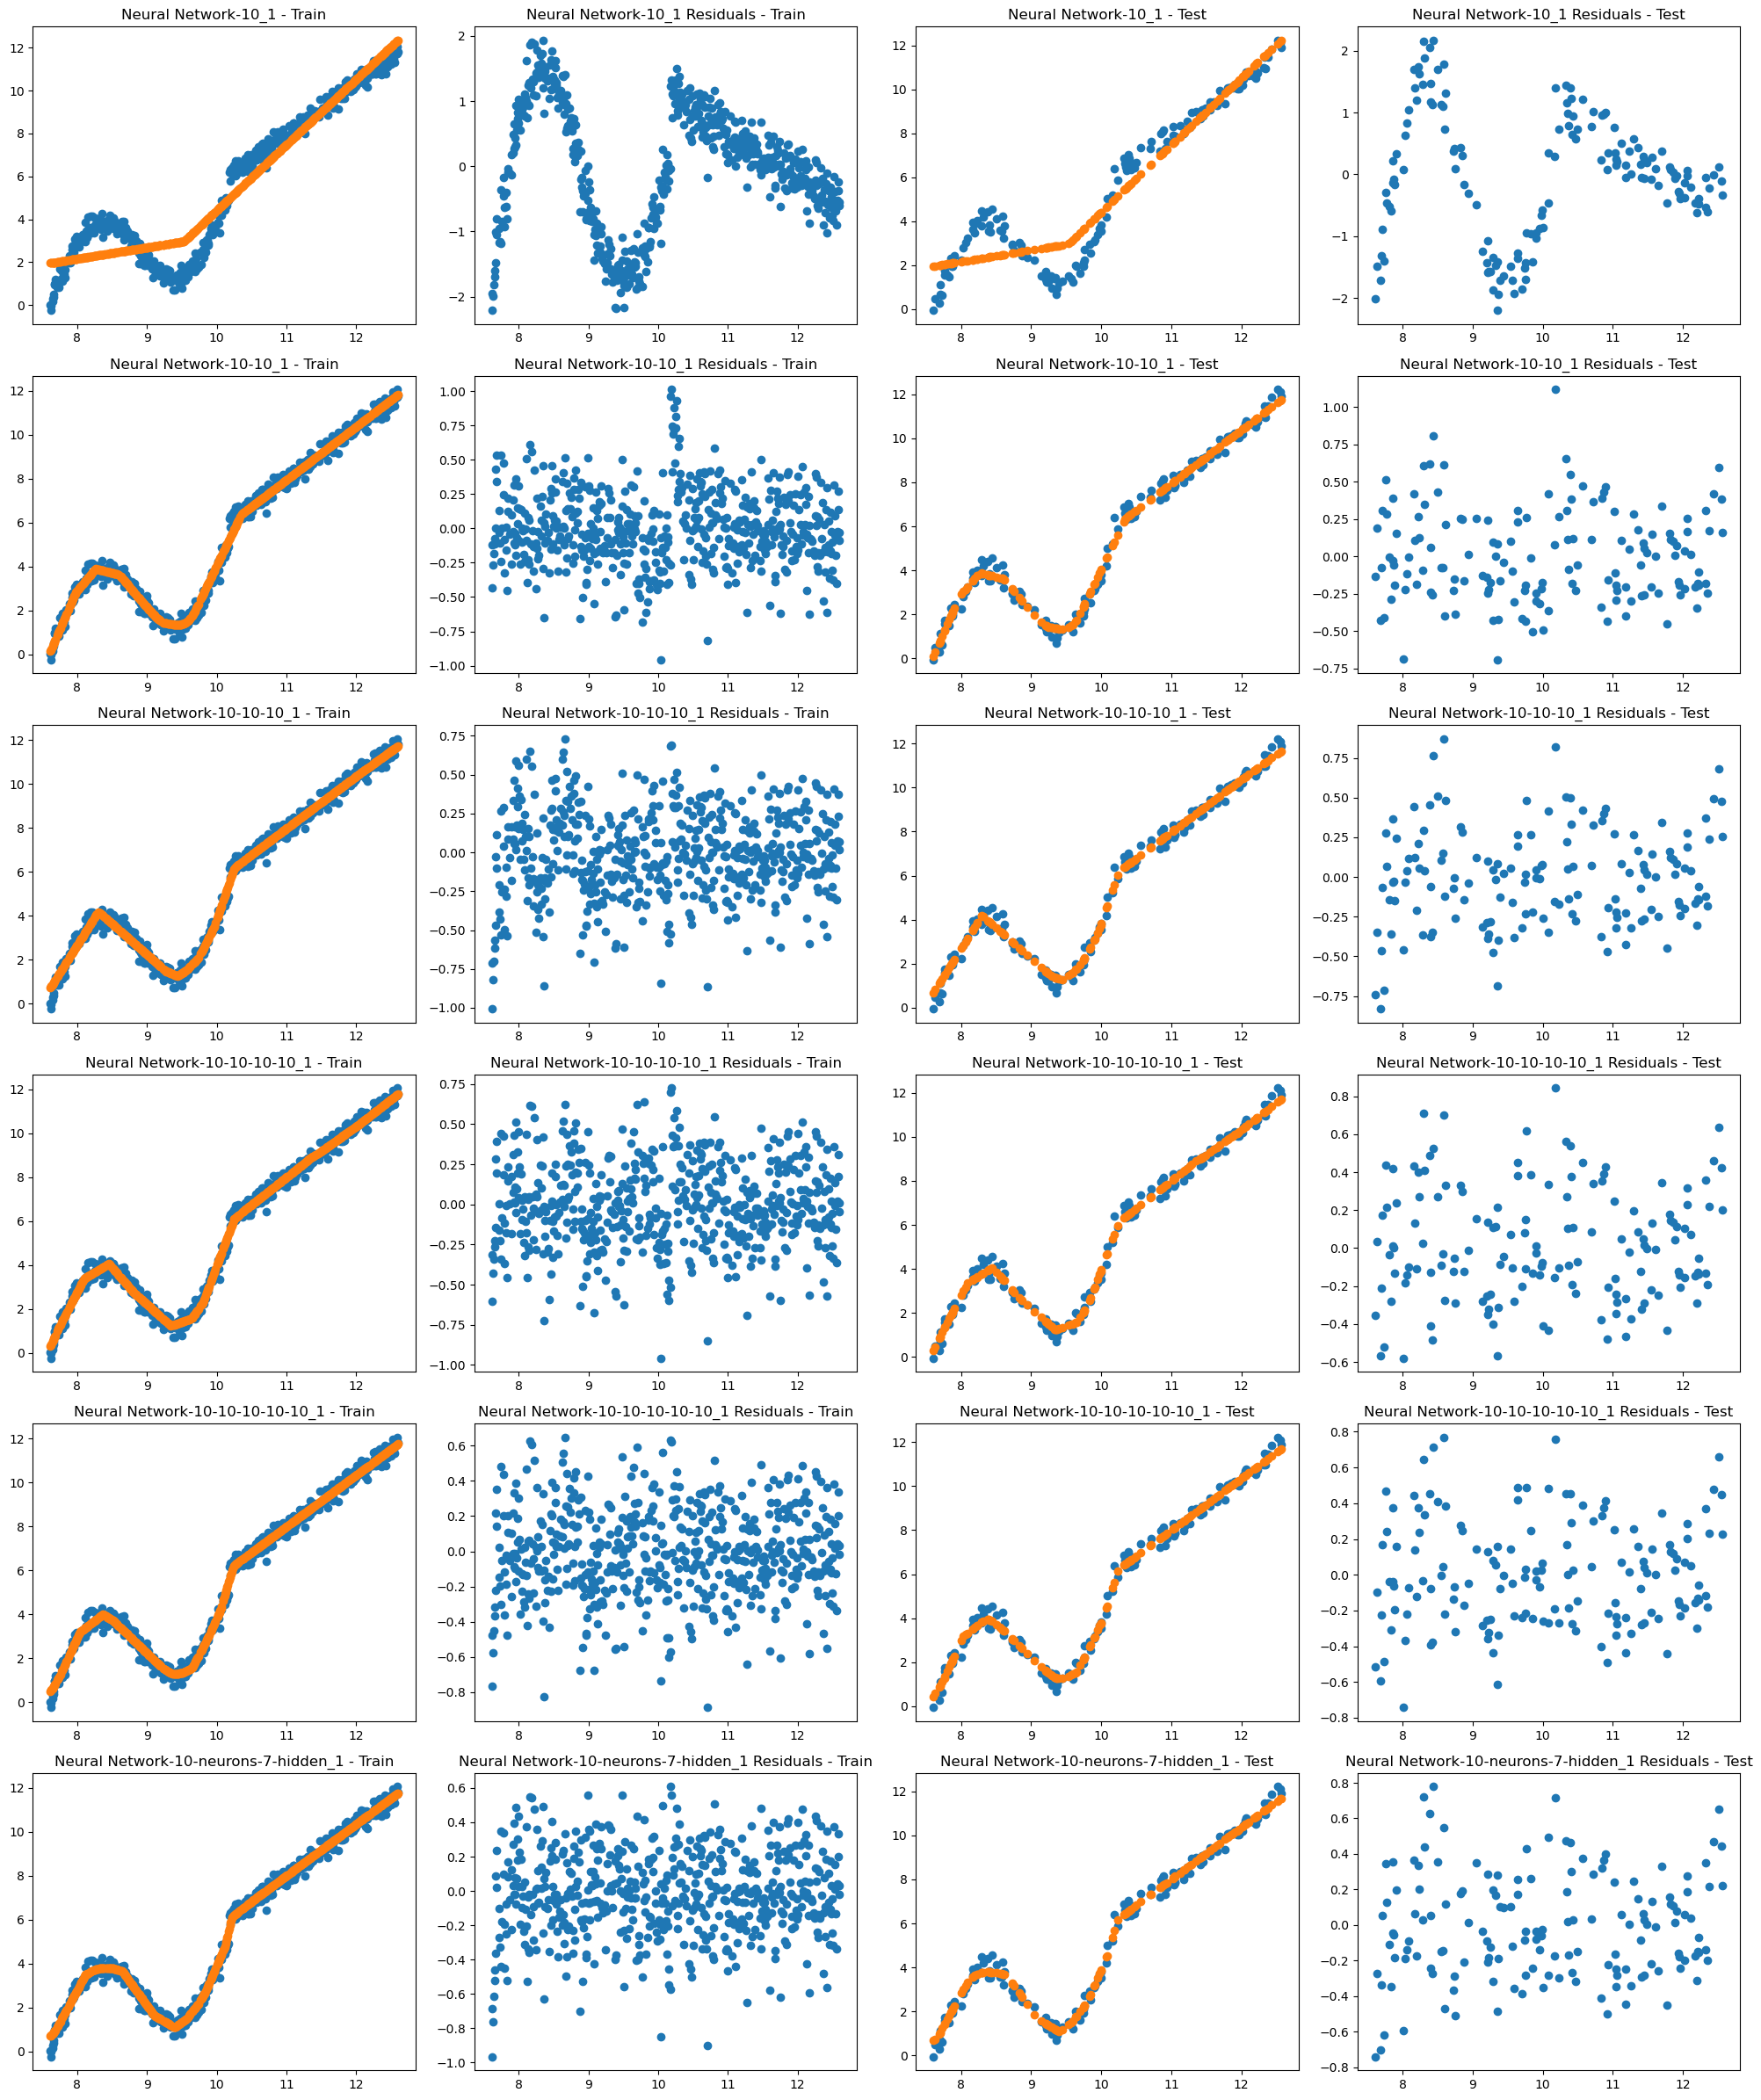

In [18]:
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
def generate_poly_features_by_degrees(degrees, i):
    poly = PolynomialFeatures(degree=degrees[i])
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    return poly,X_train_poly,X_test_poly

def convert_to_standardized_form(X_train_poly, X_test_poly):
    scaler = StandardScaler()
    X_train_poly = scaler.fit_transform(X_train_poly)
    X_test_poly = scaler.transform(X_test_poly)
    return X_train_poly,X_test_poly

degrees = [1]
# Algorithms
algorithms = {
        'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
        'Neural Network-10-10': MLPRegressor(hidden_layer_sizes=[10,10], max_iter=20000),
        'Neural Network-10-10-10': MLPRegressor(hidden_layer_sizes=[10,10,10], max_iter=20000),
        'Neural Network-10-10-10-10': MLPRegressor(hidden_layer_sizes=[10,10,10,10], max_iter=20000),
        'Neural Network-10-10-10-10-10': MLPRegressor(hidden_layer_sizes=[10,10,10,10,10], max_iter=20000),
        'Neural Network-10-neurons-7-hidden': MLPRegressor(hidden_layer_sizes=[10,10,10,10,10,10,10], max_iter=20000),
    }

# Metric tables
metric_table_train = pd.DataFrame()
metric_table_test = pd.DataFrame()
# Create a grid of subplots
fig, axs = plt.subplots(len(algorithms) * len(degrees), 4, figsize=(20, 4 * len(algorithms)))
fig_row = -1


def calculate_r2_rmse(algorithm, X_train_poly, X_test_poly, y_train_pred, y_test_pred):
    r2_train = algorithm.score(X_train_poly, y_train)
    rmse_train = root_mean_squared_error(y_train, y_train_pred)

        # Test metrics
    r2_test = algorithm.score(X_test_poly, y_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    return r2_train,rmse_train,r2_test,rmse_test

def calculate_residual_stats(y_train_pred, y_test_pred):
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    durbin_watson_stat_train = sm.stats.durbin_watson(residuals_train)
    jb_stat_train, jb_p_value_train, _, _ = sm.stats.jarque_bera(residuals_train)

    durbin_watson_stat_test = sm.stats.durbin_watson(residuals_test)
    jb_stat_test, jb_p_value_test, _, _ = sm.stats.jarque_bera(residuals_test)
    return residuals_train,residuals_test,durbin_watson_stat_train,jb_stat_train,jb_p_value_train,durbin_watson_stat_test,jb_stat_test,jb_p_value_test

def prepare_metrics(degrees, metric_table_train, metric_table_test, algorithm_name, i, r2_train, rmse_train, r2_test, rmse_test, durbin_watson_stat_train, jb_stat_train, jb_p_value_train, durbin_watson_stat_test, jb_stat_test, jb_p_value_test):
    metric_table_train.at[algorithm_name+'_' + str(degrees[i]), 'R-squared'] = r2_train
    metric_table_train.at[algorithm_name+'_' + str(degrees[i]), 'RMSE'] = rmse_train
    metric_table_train.at[algorithm_name+'_' + str(degrees[i]), 'Durbin-Watson'] = durbin_watson_stat_train
    metric_table_train.at[algorithm_name+'_' + str(degrees[i]), 'Jarque-Bera'] = jb_stat_train
    metric_table_train.at[algorithm_name+'_' + str(degrees[i]), 'JB P-value'] = jb_p_value_train

    metric_table_test.at[algorithm_name+'_' + str(degrees[i]), 'R-squared'] = r2_test
    metric_table_test.at[algorithm_name+'_' + str(degrees[i]), 'RMSE'] = rmse_test
    metric_table_test.at[algorithm_name+'_' + str(degrees[i]), 'Durbin-Watson'] = durbin_watson_stat_test
    metric_table_test.at[algorithm_name+'_' + str(degrees[i]), 'Jarque-Bera'] = jb_stat_test
    metric_table_test.at[algorithm_name+'_' + str(degrees[i]), 'JB P-value'] = jb_p_value_test
    

for algorithm_name, algorithm in algorithms.items():
    for i in range(len(degrees)):
        poly, X_train_poly, X_test_poly = generate_poly_features_by_degrees(degrees, i)
        X_train_poly, X_test_poly = convert_to_standardized_form(X_train_poly, X_test_poly)
        # feature_names = poly.get_feature_names_out()
        # Run the algorithms ... create metrics and plots
        # Train model
        algorithm.fit(X_train_poly, y_train)

        # Train predictions
        y_train_pred = algorithm.predict(X_train_poly)

        # Test predictions
        y_test_pred = algorithm.predict(X_test_poly)

        # Train metrics
        r2_train, rmse_train, r2_test, rmse_test = calculate_r2_rmse(algorithm, X_train_poly, X_test_poly, y_train_pred, y_test_pred)

        # Additional metrics using statsmodels for all algorithms
        residuals_train, residuals_test, durbin_watson_stat_train, jb_stat_train, jb_p_value_train, durbin_watson_stat_test, jb_stat_test, jb_p_value_test = calculate_residual_stats(y_train_pred, y_test_pred)

        # Update metric tables
        prepare_metrics(degrees, metric_table_train, metric_table_test, algorithm_name, i, r2_train, rmse_train, r2_test, rmse_test, durbin_watson_stat_train, jb_stat_train, jb_p_value_train, durbin_watson_stat_test, jb_stat_test, jb_p_value_test)

        # Create the plots
        fig_row = fig_row+1

        axs[fig_row, 0].scatter(X_train, y_train)
        axs[fig_row, 0].scatter(X_train, y_train_pred)
        axs[fig_row, 0].set_title(algorithm_name+'_' + str(degrees[i]) + " - Train")

        axs[fig_row, 1].scatter(X_train, residuals_train)
        axs[fig_row, 1].set_title(algorithm_name+'_' + str(degrees[i]) + " Residuals - Train")

        axs[fig_row, 2].scatter(X_test, y_test)
        axs[fig_row, 2].scatter(X_test, y_test_pred)
        axs[fig_row, 2].set_title(algorithm_name+'_' + str(degrees[i]) + " - Test")

        axs[fig_row, 3].scatter(X_test, residuals_test)
        axs[fig_row, 3].set_title(algorithm_name+'_' + str(degrees[i]) + " Residuals - Test")

############################
plt.tight_layout()
plt.show()
####################################


In [19]:
# Display the metrics' Tables
print("Metrics - Train Data:\n")
print(metric_table_train.to_string())
print("-------------------------------------------------")

print("Metrics - Test Data:\n")
print(metric_table_test.to_string())

Metrics - Train Data:

                                      R-squared      RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Neural Network-10_1                    0.927440  0.930586       0.136435    17.792194    0.000137
Neural Network-10-10_1                 0.993573  0.276958       1.528368    19.764150    0.000051
Neural Network-10-10-10_1              0.993437  0.279873       1.497190     6.317884    0.042471
Neural Network-10-10-10-10_1           0.993989  0.267854       1.631846     0.614376    0.735512
Neural Network-10-10-10-10-10_1        0.994310  0.260590       1.722532     2.009063    0.366216
Neural Network-10-neurons-7-hidden_1   0.994443  0.257519       1.760608     9.166380    0.010222
-------------------------------------------------
Metrics - Test Data:

                                      R-squared      RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Neural Network-10_1                    0.917166  1.013354       0.169198     2.542414    0.280493
Neural Network-10-10_1 